# TP 04 — TensorFlow/Keras

In [22]:
"""
TP 04 — TensorFlow/Keras
Objectif : construire un pipeline complet de Deep Learning.
"""

'\nTP 04 — TensorFlow/Keras\nObjectif : construire un pipeline complet de Deep Learning.\n'

In [23]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, accuracy_score, mean_squared_error

In [24]:
data = load_breast_cancer()

In [25]:
X, y = data.data, data.target

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
X_train.shape[1]

30

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [32]:
history = model.fit(X_train, y_train, epochs=25, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7308 - loss: 0.5629 - val_accuracy: 0.9121 - val_loss: 0.4193
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8929 - loss: 0.3755 - val_accuracy: 0.9670 - val_loss: 0.2776
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9231 - loss: 0.2690 - val_accuracy: 0.9670 - val_loss: 0.1975
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9423 - loss: 0.2035 - val_accuracy: 0.9780 - val_loss: 0.1510
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9560 - loss: 0.1703 - val_accuracy: 0.9780 - val_loss: 0.1222
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9615 - loss: 0.1351 - val_accuracy: 0.9780 - val_loss: 0.1038
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1292 - val_accuracy: 0.9890 - val_loss: 0.0884
Epoch 8/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - loss: 0.1297 - val_accuracy: 0.9890 - val_l

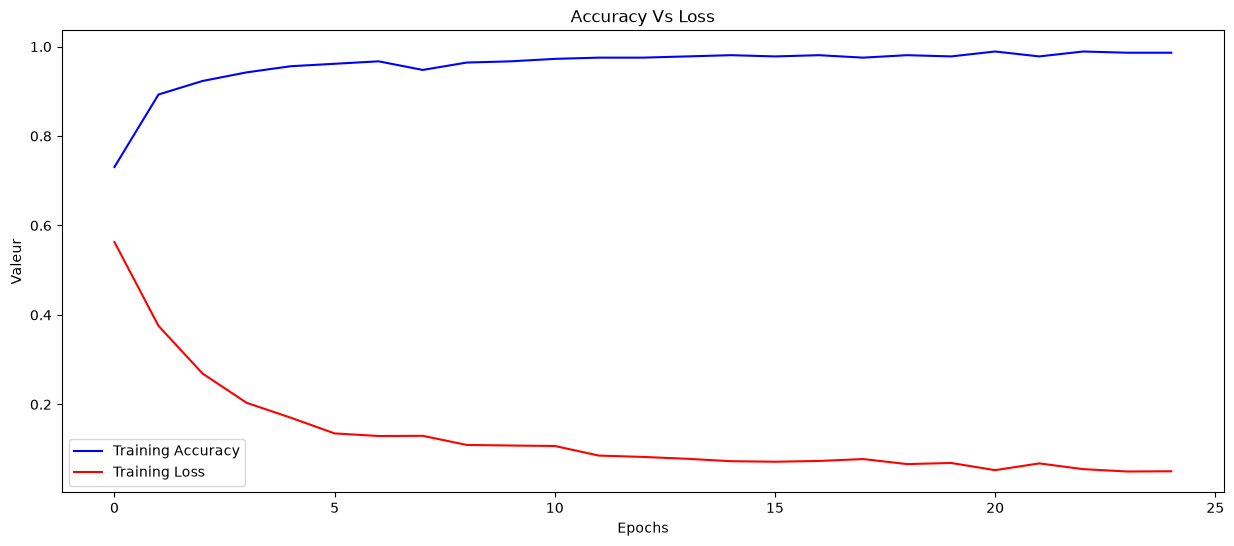

In [38]:
epoch_accuracy = history.history["accuracy"]
epoch_val_accuracy = history.history["val_accuracy"]

epoch_loss = history.history["loss"]
epoch_val_loss = history.history["val_loss"]

plt.figure(figsize=(15, 6))
plt.plot(range(0, len(epoch_accuracy)), epoch_accuracy, color='blue', label='Training Accuracy')
plt.plot(range(0, len(epoch_loss)), epoch_loss, color='red', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Valeur')
plt.title('Accuracy Vs Loss')
plt.legend()
plt.plot()
plt.show()

In [33]:
loss, accuracy = model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9561 - loss: 0.0941 


In [34]:
print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.9561403393745422


In [35]:
pred = (model.predict(X_test, verbose=1) >= 0.5).astype(int)
print(classification_report(y_test, pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [36]:
# Sauvegarde du modele
model.save("model_keras_model.keras")
print("model saved")

model saved
